### **Estudo do Alinhamento entre as Imagens (12/03/2026).**
1. Reavaliar o alinhamento com recorte. Observar as transformações img(i) = M*img(i+1).
2. Aplicar a transformação para todas as imagens, antes do recorte, através das escalas acumuladas.
3. Recortar os pixels excedentes.
4. Gerar mapa binário de pixels selecionados a partir do laplaciano.

**ECC Transform:** Avalia o coeficiente de correlação entre duas imagens (-1, 1).

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import re
import os

In [2]:
def load_images_from_folder(folder):
    """
    Ordena um conjunto de imagens a partir de uma dataset contendo ordenação 
    númerica crescente a patir da localização da pasta de origem.
    
    """
    
    images = []
    
    try:
        all_files = os.listdir(folder)
    except FileNotFoundError:
        print(f"Erro: A pasta '{folder}' não foi encontrada.")
        return []

    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    image_files = [f for f in all_files if f.lower().endswith(valid_extensions)]

    def extract_number(filename):
        match = re.search(r'(\d+)', filename)
        if match:
            return int(match.group(1))
        return 0 

    sorted_files = sorted(image_files, key=extract_number)
    
    print(f"\nOrdem de carregamento detectada: {sorted_files[:5]} ...")

    for filename in sorted_files:
        img_path = os.path.join(folder, filename)
        img = cv.imread(img_path)
        
        if img is not None:
            images.append(img)
        else:
            print(f"Aviso: Não foi possível ler {filename}")

    return images


In [3]:
def analyze_keypoint_density(aligned_images, desvios_padrao=1, show=True):
    """
    Analisa a qualidade do foco contando a densidade de pontos de interesse (Keypoints)
    e aplica um filtro estatístico (Gaussiano) para selecionar as imagens úteis.
    
    Args:
        aligned_images: Lista de imagens.
        desvios_padrao: Fator de corte (Z-score).
        show: Se True, plota o gráfico de distribuição.
        
    Returns:
        imagens_filtradas: Sublista apenas com as imagens focadas.
        indices_uteis: Lista dos índices originais mantidos.
        range_z: Tupla (inicio, fim) para referência.
    """
    print(f"--- ANÁLISE DE DENSIDADE DE KEYPOINTS (Gaussian Cut: {desvios_padrao}σ) ---")
    
    # Inicializa detector (ORB é rápido e robusto a ruído)
    # Ajustamos nfeatures para um valor alto para não saturar
    orb = cv.ORB_create(nfeatures=10000, scoreType=cv.ORB_HARRIS_SCORE)
    
    keypoint_counts = []
    
    # 1. Extração de Dados
    for i, img in enumerate(aligned_images):
        if img.ndim == 3:
            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        else:
            gray = img
            
        # Detectar keypoints (não precisamos dos descritores, apenas os pontos)
        kps = orb.detect(gray, None)
        count = len(kps)
        keypoint_counts.append(count)

    counts_arr = np.array(keypoint_counts)
    
    # 2. Análise Estatística (Gaussiana)
    media = np.mean(counts_arr)
    std = np.std(counts_arr)
    
    # Definição do Limiar (Threshold)
    # Queremos apenas as imagens que têm MUITO mais detalhes que a média
    limiar_corte = media - (desvios_padrao * std)
    
    print(f"Estatísticas -> Média: {media:.1f} pts | Std: {std:.1f} pts")
    print(f"Critério de Corte: > {limiar_corte:.1f} pontos")
    
    # 3. Filtragem
    indices_uteis = np.where(counts_arr > limiar_corte)[0]
    
    if len(indices_uteis) == 0:
        print("ALERTA: Nenhuma imagem passou no critério. O desvio padrão está muito alto ou as imagens estão sem textura.")
        return [], [], (0,0)
    
    # Para manter a continuidade do volume 3D, pegamos do primeiro ao último índice válido
    idx_start = indices_uteis[0]
    idx_end = indices_uteis[-1]
    
    imagens_filtradas = aligned_images[idx_start : idx_end+1]
    
    print(f"Seleção: Mantendo índices {idx_start} até {idx_end} (Total: {len(imagens_filtradas)} imagens)")

    # 4. Visualização
    if show:
        plt.figure(figsize=(10, 6))
        
        # Plot da curva de densidade
        x = range(len(aligned_images))
        plt.plot(x, counts_arr, label='Qtd. Keypoints', color='navy', linewidth=2)
        plt.fill_between(x, 0, counts_arr, alpha=0.1, color='blue')
        
        # Plot da área selecionada
        plt.axhline(y=media, color='gray', linestyle=':', label='Média')
        plt.axhline(y=limiar_corte, color='red', linestyle='--', label=f'Corte ({desvios_padrao}σ)')
        
        # Destacar a região aprovada
        plt.axvspan(idx_start, idx_end, color='green', alpha=0.2, label='Volume de Foco Útil')
        
        plt.title("Distribuição Gaussiana de Foco")
        plt.xlabel("Índice da Imagem (Profundidade Z)")
        plt.ylabel("Contagem de Pontos de Interesse")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return imagens_filtradas, indices_uteis, (idx_start, idx_end)


Ordem de carregamento detectada: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg'] ...
--- ANÁLISE DE DENSIDADE DE KEYPOINTS (Gaussian Cut: 0.5σ) ---
Estatísticas -> Média: 4849.9 pts | Std: 4313.6 pts
Critério de Corte: > 2693.1 pontos
Seleção: Mantendo índices 29 até 62 (Total: 34 imagens)


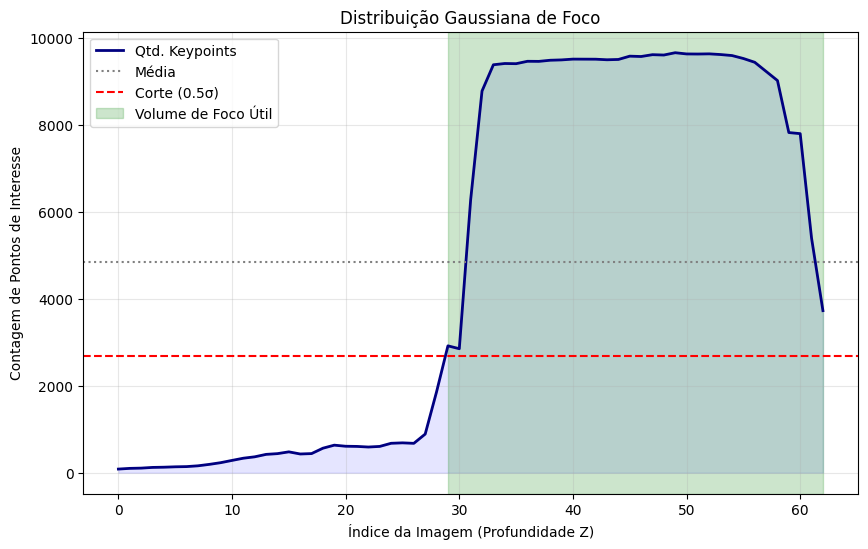

In [4]:
# Aplicar a Seleção das Imagens do Conjunto (com base nos Pontos de Interesse).
raw_images = load_images_from_folder('../images/ordered')
images, idx, (start, end) = analyze_keypoint_density(raw_images, 0.5)

In [ ]:
def align_images(images):
    """
    1. Alinha usando ECC.
    2. Rastreia as bordas pretas criadas pelo zoom/shift.
    3. Recorta o resultado final para eliminar áreas sem dados.
    """

    if not images: return [], []
    
    print(f"\nFase 1.2: Alinhamento ECC com Recorte ({len(images)} imagens)")
    
    # Referência - Ground Truth.
    ref_img = images[0]
    ref_gray = cv.cvtColor(ref_img, cv.COLOR_BGR2GRAY).astype(np.float32)
    height, width = ref_img.shape[:2]
    
    aligned_images = [ref_img]
    scales = [1.0]
    acummulated_scales = scales.copy()
    common_mask = np.ones((height, width), dtype=np.uint8) * 255
    
    # Configuração ECC (Critérios de parada).
    warp_mode = cv.MOTION_AFFINE
    criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 50, 1e-5)
    warp_matrix = np.eye(2, 3, dtype=np.float32)

    for i in range(1, len(images)):
        img_curr = images[i]
        curr_gray = cv.cvtColor(img_curr, cv.COLOR_BGR2GRAY).astype(np.float32)
        
        try:
            # Passo ECC
            step_matrix = np.eye(2, 3, dtype=np.float32)
            cc, step_matrix = cv.findTransformECC(ref_gray, curr_gray, step_matrix, warp_mode, criteria)
            
            # Acumula Matriz (dot product).
            step_3x3 = np.vstack([step_matrix, [0, 0, 1]])
            warp_3x3_accum = np.vstack([warp_matrix, [0,0,1]])
            combined = np.dot(step_3x3, warp_3x3_accum)
            warp_matrix = combined[:2, :]
            
            # Alinha a Imagem.
            img_aligned = cv.warpAffine(img_curr, warp_matrix, (width, height), 
                                         flags=cv.INTER_LINEAR + cv.WARP_INVERSE_MAP,
                                         borderMode=cv.BORDER_CONSTANT, borderValue=(0,0,0))
            
            aligned_images.append(img_aligned)
            
            # Atualiza a Máscara de Validade.
            mask_curr = np.ones((height, width), dtype=np.uint8) * 255            
            mask_warped = cv.warpAffine(mask_curr, warp_matrix, (width, height), 
                                         flags=cv.INTER_NEAREST + cv.WARP_INVERSE_MAP,
                                         borderMode=cv.BORDER_CONSTANT, borderValue=0)
            
            common_mask = cv.bitwise_and(common_mask, mask_warped)
            
            # Calcula Escala.
            s_x = np.sqrt(warp_matrix[0,0]**2 + warp_matrix[1,0]**2)
            scales.append(s_x)
            acummulated_scales.append(acummulated_scales[-1]*s_x)
            
            print(f">> Img {i} Alinhada (ECC). Escala: {s_x:.4f}")

            # Atualiza Referência.
            ref_gray = curr_gray
            
        except cv.error:
            print(f"[OS] Falha ECC na img {i}. Usando anterior.")
            aligned_images.append(aligned_images[-1])
            scales.append(scales[-1])
            acummulated_scales.append(acummulated_scales[-1]**2)
            

    # Corte
    contours, _ = cv.findContours(common_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if contours:
        x, y, w, h = cv.boundingRect(contours[0])
        print(f"\n[OS] Área válida detectada: \n>> X: {x}, Y: {y}, Largura: {w}, Altura: {h}")
        print(f"[OS] Pixels perdidos nas bordas: \n>> Horizontal: {width-w}, Vertical: {height-h}")
        
        final_images = []
        for img in aligned_images:
            # Recorta todas as imagens no mesmo retângulo seguro.
            cropped = img[y:y+h, x:x+w]
            final_images.append(cropped)
            
        return final_images, scales, acummulated_scales
    else:
        print("[OS] Erro Crítico: A máscara comum ficou vazia! (Overlap insuficiente). Retornando originais.")
        return aligned_images, scales, acummulated_scales


In [6]:
# Aplicar Alinhamento ECC nas Imagens Selecionadas.
aligned_images, scales, accm_scales = align_images(images)


Fase 1.2: Alinhamento ECC com Recorte (34 imagens)
>> Img 1 Alinhada (ECC). Escala: 0.9996
>> Img 2 Alinhada (ECC). Escala: 1.0105
>> Img 3 Alinhada (ECC). Escala: 1.0185
>> Img 4 Alinhada (ECC). Escala: 1.0312
>> Img 5 Alinhada (ECC). Escala: 1.0322
>> Img 6 Alinhada (ECC). Escala: 1.0322
>> Img 7 Alinhada (ECC). Escala: 1.0343
>> Img 8 Alinhada (ECC). Escala: 1.0354
>> Img 9 Alinhada (ECC). Escala: 1.0369
>> Img 10 Alinhada (ECC). Escala: 1.0386
>> Img 11 Alinhada (ECC). Escala: 1.0388
>> Img 12 Alinhada (ECC). Escala: 1.0388
>> Img 13 Alinhada (ECC). Escala: 1.0389
>> Img 14 Alinhada (ECC). Escala: 1.0389
>> Img 15 Alinhada (ECC). Escala: 1.0388
>> Img 16 Alinhada (ECC). Escala: 1.0453
>> Img 17 Alinhada (ECC). Escala: 1.0505
>> Img 18 Alinhada (ECC). Escala: 1.0543
>> Img 19 Alinhada (ECC). Escala: 1.0555
>> Img 20 Alinhada (ECC). Escala: 1.0628
>> Img 21 Alinhada (ECC). Escala: 1.0637
>> Img 22 Alinhada (ECC). Escala: 1.0745
>> Img 23 Alinhada (ECC). Escala: 1.0820
>> Img 24 Alin

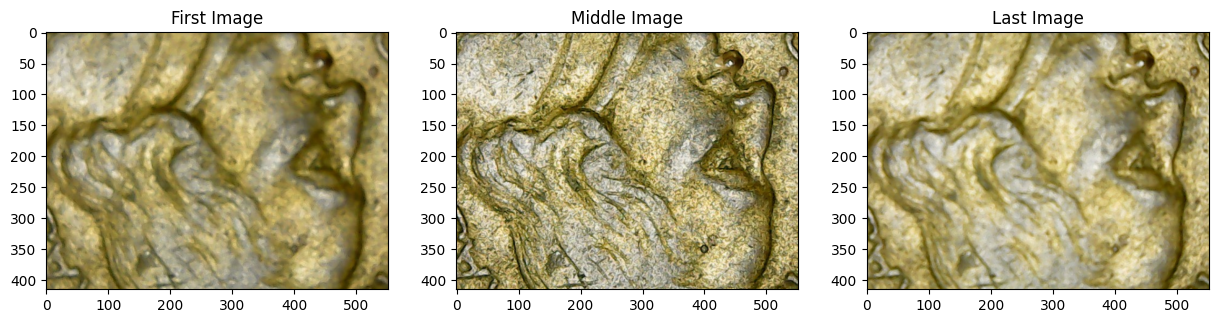

In [ ]:
# Exibindo as imagens resultantes do recorte em três pontos da pilha.

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(cv.cvtColor(aligned_images[0], cv.COLOR_BGR2RGB), cmap='jet')
ax2.imshow(cv.cvtColor(aligned_images[20], cv.COLOR_BGR2RGB), cmap='jet')
ax3.imshow(cv.cvtColor(aligned_images[-1], cv.COLOR_BGR2RGB), cmap='jet')

ax1.set_title("First Image")
ax2.set_title("Middle Image")
ax3.set_title("Last Image")

plt.show()

Agora, o objetivo é gerar um mapa binário dos pixels com maior magnitude de laplaciano.

In [ ]:
def binary_map(aligned_images, target_layer, blur_window=3):
    """
    Calcula o Depth from Focus e retorna um mapa binário contendo apenas 
    os pixels cujo foco máximo ocorreu em uma camada (imagem) específica.
    
    Args:
        aligned_images: Lista de imagens alinhadas.
        target_layer: Índice da imagem (camada) que você deseja isolar.
        blur_window: Tamanho da janela do filtro Gaussiano para reduzir ruído.
        
    Returns:
        binary_map: Matriz 2D em formato uint8 (0 e 255) representando a máscara.
        index_map: O mapa completo com os índices de foco de todos os pixels.
    """
    print(f"Calculando máscara binária para a Camada {target_layer}...")
    
    gray_images = []
    for img in aligned_images:
        if img.ndim == 3:
            gray_images.append(cv.cvtColor(img, cv.COLOR_BGR2GRAY))
        else:
            gray_images.append(img)
            
    stack = np.dstack(gray_images)
    h, w, n_imgs = stack.shape
    
    if target_layer < 0 or target_layer >= n_imgs:
        raise ValueError(f"O índice target_layer deve estar entre 0 e {n_imgs - 1}.")
        
    focus_cube = np.zeros_like(stack, dtype=np.float32)
    
    for i in range(n_imgs):
        img_camada = stack[:, :, i]
        
        blur = cv.GaussianBlur(img_camada, (blur_window, blur_window), 0)
        
        # Magnitude do Laplaciano
        lap = np.abs(cv.Laplacian(blur, cv.CV_64F))
        focus_cube[:, :, i] = lap
        
    index_map = np.argmax(focus_cube, axis=2)
    
    max_focus_raw = np.max(focus_cube, axis=2)
    
    # Intervalo uint8 (0 a 255).
    max_focus_image_normalized = cv.normalize(max_focus_raw, None, 
                                               alpha=0, beta=255, 
                                               norm_type=cv.NORM_MINMAX, 
                                               dtype=cv.CV_8U)
    
    boolean_mask = (index_map == target_layer)
    
    binary_map = (boolean_mask * 255).astype(np.uint8)
    
    return binary_map, index_map, max_focus_image_normalized, max_focus_raw

In [ ]:
target_layer = 20 # Camada observada.

mapa_binario, mapa_total, foco_maximo, _ = binary_map(aligned_images, target_layer=target_layer)

Calculando máscara binária para a Camada 20...


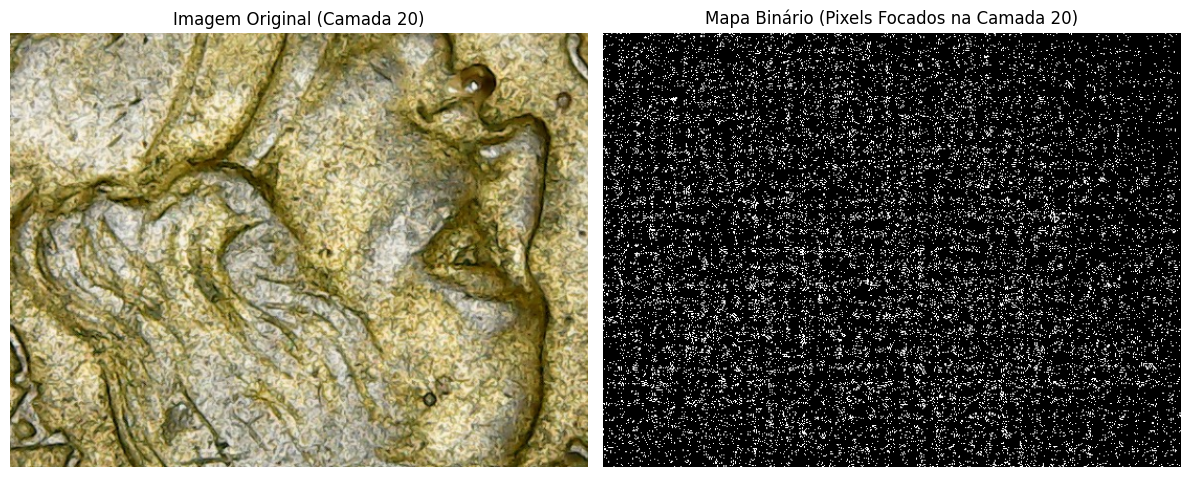

In [ ]:
# Exibindo o Mapa Binário.

plt.figure(figsize=(12, 6))
    
# Imagem original daquela camada
plt.subplot(1, 2, 1)
if aligned_images[target_layer].ndim == 3:
    plt.imshow(cv.cvtColor(aligned_images[target_layer], cv.COLOR_BGR2RGB))
else:
    plt.imshow(aligned_images[target_layer], cmap='gray')
plt.title(f"Imagem Original (Camada {target_layer})")
plt.axis('off')

# Mapa Binário
plt.subplot(1, 2, 2)
plt.imshow(mapa_binario, cmap='gray')
plt.title(f"Mapa Binário (Pixels Focados na Camada {target_layer})")
plt.axis('off')

plt.tight_layout()
plt.show()


Exibindo uma representação da imagem com os maiores valores de laplace.

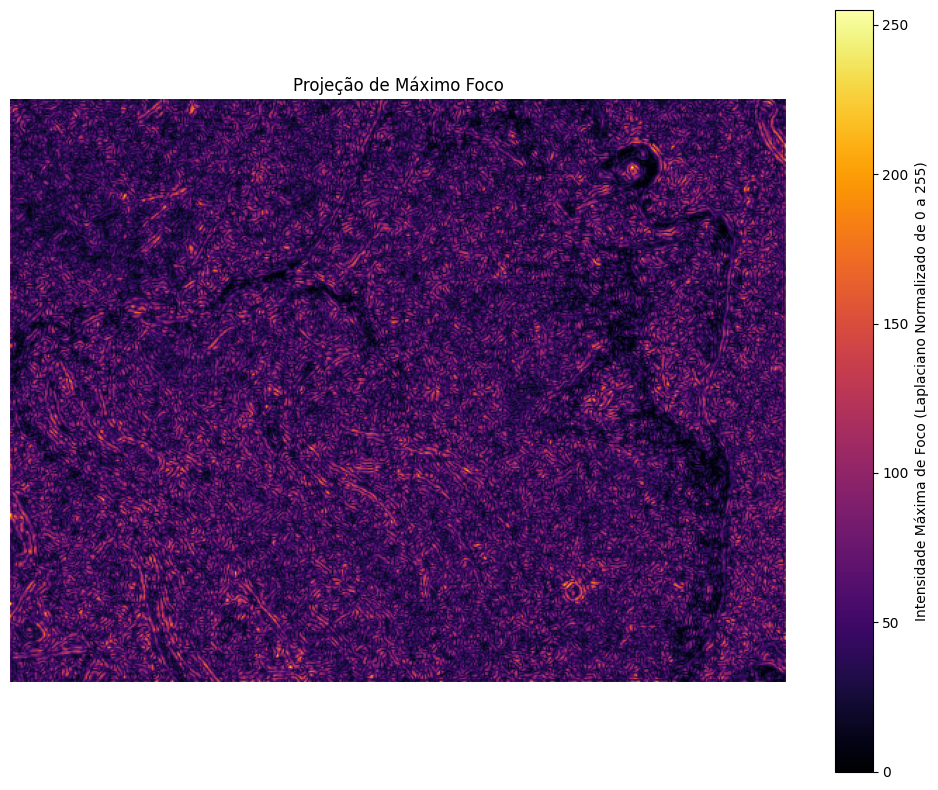

In [46]:
plt.figure(figsize=(10, 8))
    
plt.imshow(foco_maximo, cmap='inferno') 
plt.colorbar(label='Intensidade Máxima de Foco (Laplaciano Normalizado de 0 a 255)')
plt.title("Projeção de Máximo Foco")
plt.axis('off')

plt.tight_layout()
plt.show()